In [1]:
# Cellule: Installation et téléchargement via KaggleHub
!pip install kagglehub -q

import kagglehub
import os
import shutil
import glob

print("Téléchargement du dataset HAM10000 via KaggleHub...")
print("-" * 50)

# Télécharger le dataset
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print(f"✓ Dataset téléchargé dans: {path}")

# Créer le dossier cible
os.makedirs('/content/skin_data/images', exist_ok=True)

# Trouver et copier les images
print("\nRecherche des images...")
image_count = 0

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.jpg'):
            src = os.path.join(root, file)
            dst = os.path.join('/content/skin_data/images', file)
            shutil.copy2(src, dst)
            image_count += 1

# Copier les métadonnées
for root, dirs, files in os.walk(path):
    for file in files:
        if file == 'HAM10000_metadata.csv':
            shutil.copy2(os.path.join(root, file), '/content/skin_data/')
            print("✓ Métadonnées copiées")
            break

print(f"\n✅ {image_count} images copiées dans /content/skin_data/images/")

# Vérification
images = glob.glob('/content/skin_data/images/*.jpg')
print(f"📊 {len(images)} images disponibles")

Téléchargement du dataset HAM10000 via KaggleHub...
--------------------------------------------------
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
✓ Dataset téléchargé dans: /kaggle/input/skin-cancer-mnist-ham10000

Recherche des images...
✓ Métadonnées copiées

✅ 20030 images copiées dans /content/skin_data/images/
📊 10015 images disponibles


In [8]:
# Cellule 1: Imports et configuration (OK mais ajout gestion mémoire)
import os
import gc
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

# Configuration
plt.style.use('seaborn-v0_8')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Libération mémoire
torch.cuda.empty_cache() if torch.cuda.is_available() else None
gc.collect()

# Set random seeds
def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(42)

Using device: cpu


In [9]:
# Cellule 2: Dataset (OK)
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id'] + '.jpg'
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = cv2.imread(img_path)
            if image is None:
                raise FileNotFoundError
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        except:
            image = np.zeros((224, 224, 3), dtype=np.uint8)

        label_idx = self.df.loc[idx, 'label_idx']

        if self.transform:
            image = self.transform(image)

        return image, label_idx

# Augmentations
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [10]:
# Cellule 3: Chargement des données (batch_size réduit pour RAM)
metadata = pd.read_csv('/content/skin_data/HAM10000_metadata.csv')

# Vérification des images
existing_images = set([os.path.basename(f).replace('.jpg', '')
                       for f in glob.glob('/content/skin_data/images/*.jpg')])
metadata['exists'] = metadata['image_id'].isin(existing_images)
metadata = metadata[metadata['exists']].reset_index(drop=True)

# Encodage
label_encoder = LabelEncoder()
metadata['label_idx'] = label_encoder.fit_transform(metadata['dx'])

class_names = label_encoder.classes_
class_counts = metadata['dx'].value_counts()

print("Distribution des classes:")
for dx, count in class_counts.items():
    print(f"  {dx}: {count} ({count/len(metadata)*100:.1f}%)")

# Division
train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    stratify=metadata['dx'],
    random_state=42
)

print(f"\nTrain set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")

# Datasets
train_dataset = SkinLesionDataset(train_df, '/content/skin_data/images', transform=train_transforms)
val_dataset = SkinLesionDataset(val_df, '/content/skin_data/images', transform=val_transforms)

# Poids pour sampling
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['dx']),
    y=train_df['dx']
)
class_weights_dict = dict(zip(np.unique(train_df['dx']), class_weights))
sample_weights = [class_weights_dict[dx] for dx in train_df['dx']]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# DataLoaders - num_workers=2 au lieu de 4 pour économiser RAM
batch_size = 16  # Réduit de 32 à 16 pour économiser RAM
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"\nPoids des classes: {class_weights_tensor.cpu().numpy()}")

# Libération mémoire
del metadata
gc.collect()

Distribution des classes:
  nv: 6705 (66.9%)
  mel: 1113 (11.1%)
  bkl: 1099 (11.0%)
  bcc: 514 (5.1%)
  akiec: 327 (3.3%)
  vasc: 142 (1.4%)
  df: 115 (1.1%)

Train set: 8012 images
Validation set: 2003 images

Poids des classes: [ 4.368593   2.7848454  1.302129  12.440994   1.2860353  0.2133802
 10.0401   ]


51

In [11]:
# Cellule 4: Modèle (CORRIGÉ)
class ImprovedResNet50(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.3, freeze_layers=False):
        super(ImprovedResNet50, self).__init__()

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Backbone sans la fc
        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4
        )

        if freeze_layers:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate/2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def unfreeze_layers(self, num_layers=3):
        # Dégèle les derniers blocs
        trainable_params = []
        for i, (name, param) in enumerate(reversed(list(self.backbone.named_parameters()))):
            if i < num_layers * 20:
                param.requires_grad = True
                trainable_params.append(name)
            else:
                param.requires_grad = False
        print(f"✓ {len(trainable_params)} paramètres dégelés")

In [12]:
# Cellule 5: Fonctions d'entraînement (AJOUT de train_model)
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = balanced_accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = balanced_accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

# NOUVELLE FONCTION train_model
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, patience, model_name, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        # Scheduler step
        if scheduler:
            scheduler.step(val_loss)

        # Enregistrement
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f"✓ Nouveau meilleur modèle! (Acc: {val_acc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping à l'époque {epoch+1}")
                break

        # Libération mémoire
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Charger le meilleur modèle
    model.load_state_dict(torch.load(f'best_{model_name}.pth'))
    return model, history, best_val_acc

In [13]:
# Cellule 6: Entraînement (CORRIGÉ)
print("Construction du modèle...")
model = ImprovedResNet50(num_classes=7, dropout_rate=0.3, freeze_layers=False).to(device)

print("Configuration de l'entraînement...")
# Ne dégeler que si nécessaire (économie mémoire)
model.unfreeze_layers(num_layers=2)  # Réduit de 3 à 2

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Démarrage de l'entraînement...")
num_epochs = 5  # Réduit de 8 à 5 pour économiser RAM
model, history, best_acc = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=num_epochs, patience=4, model_name="improved_resnet50", device=device
)

print(f"\n✅ Entraînement terminé! Meilleure balanced accuracy: {best_acc:.4f}")

Construction du modèle...
Configuration de l'entraînement...
✓ 40 paramètres dégelés
Démarrage de l'entraînement...

Epoch 1/5
----------------------------------------


Validation: 100%|██████████| 126/126 [07:15<00:00,  3.46s/it]


Train Loss: 0.5584, Train Acc: 0.5798
Val Loss: 1.1530, Val Acc: 0.6679
✓ Nouveau meilleur modèle! (Acc: 0.6679)

Epoch 2/5
----------------------------------------


Validation: 100%|██████████| 126/126 [06:52<00:00,  3.28s/it]


Train Loss: 0.3074, Train Acc: 0.7136
Val Loss: 0.8178, Val Acc: 0.7499
✓ Nouveau meilleur modèle! (Acc: 0.7499)

Epoch 3/5
----------------------------------------


...

Train Loss: 0.2325, Train Acc: 0.7641
Val Loss: 0.7860, Val Acc: 0.7602
✓ Nouveau meilleur modèle! (Acc: 0.7602)

Epoch 4/5
----------------------------------------


Validation: 100%|██████████| 126/126 [07:33<00:00,  3.60s/it]


Train Loss: 0.2071, Train Acc: 0.7967
Val Loss: 0.7062, Val Acc: 0.8041
✓ Nouveau meilleur modèle! (Acc: 0.8041)

Epoch 5/5
----------------------------------------


Validation: 100%|██████████| 126/126 [07:51<00:00,  3.74s/it]


Train Loss: 0.1614, Train Acc: 0.8257
Val Loss: 0.6911, Val Acc: 0.7979

✅ Entraînement terminé! Meilleure balanced accuracy: 0.8041


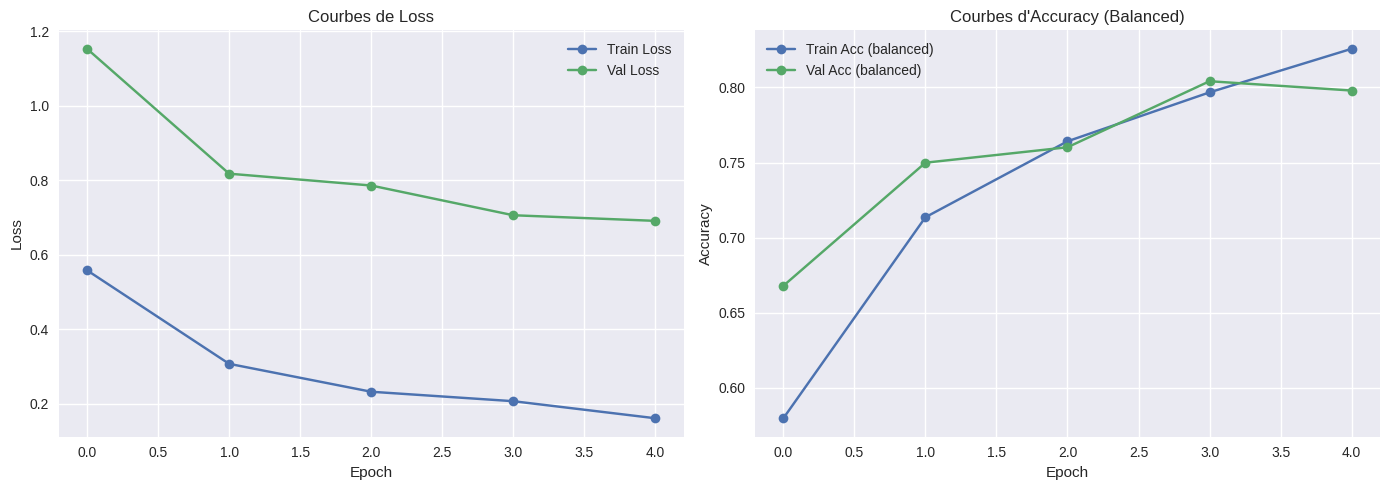

In [14]:
# Cellule 7: Visualisation (OK)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Courbes de Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train Acc (balanced)', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc (balanced)', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title("Courbes d'Accuracy (Balanced)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluation: 100%|██████████| 126/126 [07:36<00:00,  3.63s/it]



Évaluation Finale du Modèle
Loss moyenne: 0.7062
Accuracy standard: 0.6191
Balanced Accuracy: 0.8041

Classification Report
              precision    recall  f1-score   support

       akiec       0.46      0.85      0.59        65
         bcc       0.51      0.93      0.66       103
         bkl       0.49      0.70      0.57       220
          df       0.30      0.96      0.46        23
         mel       0.31      0.77      0.45       223
          nv       0.99      0.53      0.69      1341
        vasc       0.69      0.89      0.78        28

    accuracy                           0.62      2003
   macro avg       0.54      0.80      0.60      2003
weighted avg       0.81      0.62      0.65      2003



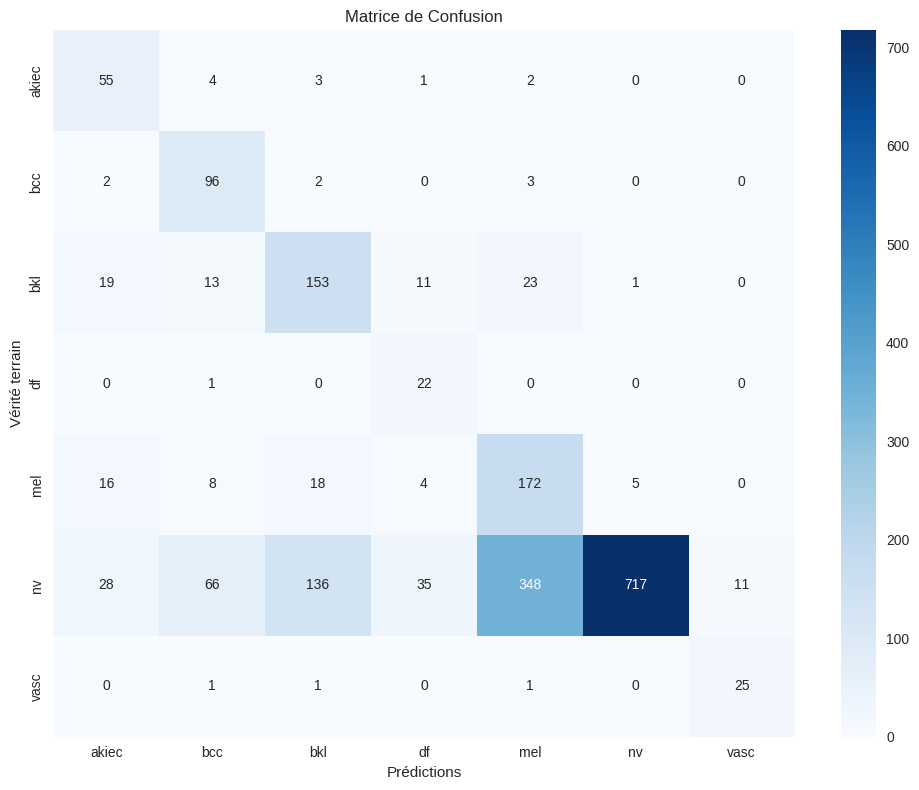

In [15]:
# Cellule 8: Évaluation (OK)
def evaluate_model(model, loader, criterion, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    standard_acc = np.mean(np.array(all_preds) == np.array(all_labels))

    print(f"\n{'='*50}")
    print("Évaluation Finale du Modèle")
    print(f"{'='*50}")
    print(f"Loss moyenne: {avg_loss:.4f}")
    print(f"Accuracy standard: {standard_acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")

    print(f"\n{'='*50}")
    print("Classification Report")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Prédictions')
    plt.ylabel('Vérité terrain')
    plt.title('Matrice de Confusion')
    plt.tight_layout()
    plt.show()

    return balanced_acc, standard_acc

val_balanced_acc, val_standard_acc = evaluate_model(
    model, val_loader, criterion, device, class_names
)

In [ ]:
# Cellule 9: Prédiction (OK)
def predict_image(model, image_path, transform, device, class_names):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image non trouvée: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        pred_class = torch.argmax(probabilities, dim=1).item()

    confidence = probabilities[0][pred_class].item()
    predicted_label = class_names[pred_class]

    top3_probs, top3_indices = torch.topk(probabilities[0], 3)
    top3_predictions = [(class_names[idx], prob.item()) for idx, prob in zip(top3_indices, top3_probs)]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f"Prédiction: {predicted_label}\nConfiance: {confidence:.2%}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    classes = [p[0] for p in top3_predictions]
    probs = [p[1] for p in top3_predictions]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(classes))]
    plt.barh(classes, probs, color=colors)
    plt.xlabel('Probabilité')
    plt.title('Top 3 Prédictions')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

    return predicted_label, confidence, top3_predictions

In [17]:
# Cellule 10: Sauvegarde (CORRIGÉ)
import pickle

results = {
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'val_balanced_acc': val_balanced_acc,
    'val_standard_acc': val_standard_acc,
    'history': history,
    'class_weights': class_weights_tensor.cpu().numpy(),
}

torch.save(results, 'improved_skin_lesion_model.pth')
print("✓ Modèle sauvegardé")

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("✓ Historique sauvegardé")

print(f"\n{'='*50}")
print("RÉSUMÉ FINAL")
print(f"{'='*50}")
print(f"Classes: {list(class_names)}")
print(f"Accuracy standard: {val_standard_acc:.4f} ({val_standard_acc*100:.2f}%)")
print(f"Balanced Accuracy: {val_balanced_acc:.4f} ({val_balanced_acc*100:.2f}%)")

✓ Modèle sauvegardé
✓ Historique sauvegardé

RÉSUMÉ FINAL
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Accuracy standard: 0.6191 (61.91%)
Balanced Accuracy: 0.8041 (80.41%)
